# Recipe Generator — Evaluation

Load the latest trained model from GCS, visualise training history, and test inference.

## 1 — Import Required Libraries

In [2]:
from utils import load_latest_model_from_gcs,  plot_losses, plot_metrics
from inference import build_vocab_helpers, generate_recipe

import pandas as pd
import numpy as np
import json

## 2 — Load the Latest Model from GCS

List all run folders under `models/` in the `recipe-generation` bucket, pick the most recent one (folders are named `YYYYMMDD_HHMMSS`), download `config.json`, `history.json`, `vocab_meta.json`, and `model.pt`, then reconstruct the model.

In [3]:
GCS_BUCKET = "recipe-generation"
GCS_MODEL_PREFIX = "models"

model, config, history, vocab_meta = load_latest_model_from_gcs(
    gcs_bucket=GCS_BUCKET,
    gcs_model_prefix=GCS_MODEL_PREFIX
)

Loading run: gs://recipe-generation/models/20260330_091043
Model loaded — 326,540 parameters
Epochs in history: 30


## 3 — Loss Curves Over Epochs

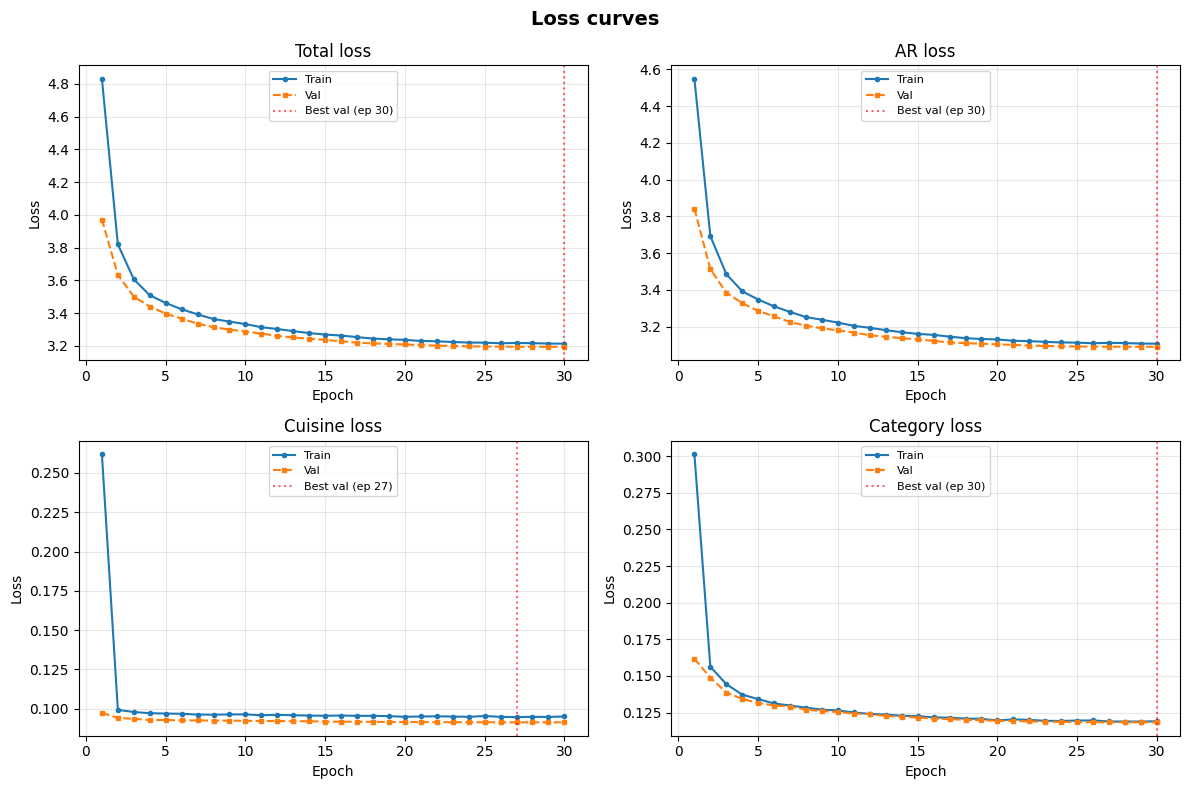

In [4]:
plot_losses(history)

## 4 — Metric Curves Over Epochs

AR accuracy                    | best val = 0.2824 (epoch 22)
Cuisine F1 (macro)             | best val = 0.0091 (epoch 14)
Category F1 (macro)            | best val = 0.0865 (epoch 24)


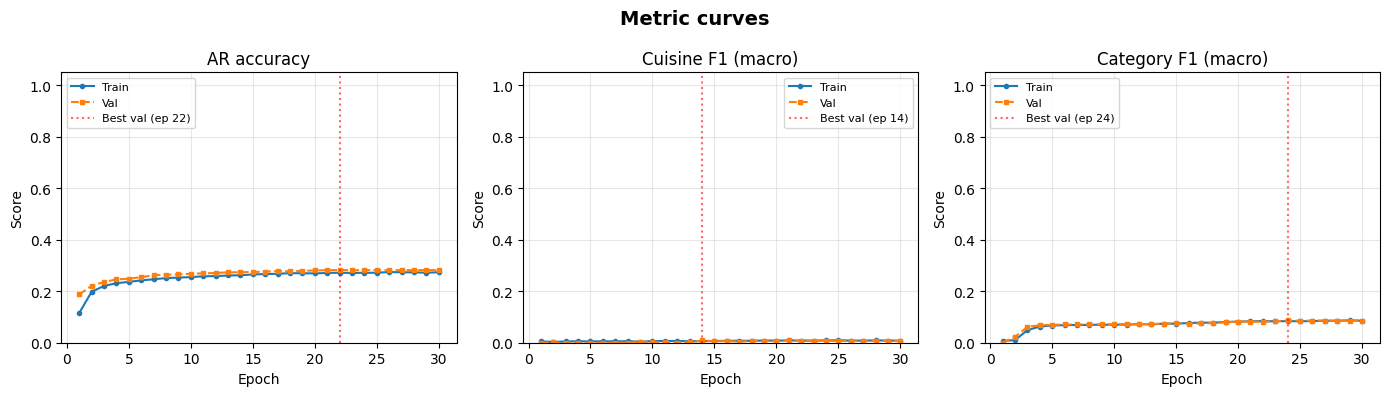

In [5]:
plot_metrics(history)

## 5 — Inference

Provide a list of known ingredients to the model.  The cell below will:
1. Autoregressively predict up to `max_new` additional ingredients (stopping when a special token is predicted or the sequence reaches `max_seq_len`).
2. Predict the most likely **cuisine** and **category** from the CLS token.

Edit `STARTER_INGREDIENTS` and `max_new` to try different recipes.

In [6]:
ingr_to_idx, idx_to_ingr, cuisine_vocab, recipe_cat_vocab, bos_idx, cls_idx, _special_ids, max_seq_len =build_vocab_helpers(vocab_meta, config)

In [7]:
# ── Try it ───────────────────────────────────────────────────────────────────
starter_ingredients = ["chicken broth"]
result = generate_recipe(
    model=model,
    starter_ingredients=starter_ingredients,
    ingr_to_idx=ingr_to_idx,
    idx_to_ingr=idx_to_ingr,
    cuisine_vocab=cuisine_vocab,
    recipe_cat_vocab=recipe_cat_vocab,
    _special_ids=_special_ids,
    bos_idx=bos_idx,
    cls_idx=cls_idx,
    max_seq_len=8,
    top_k=30,
    temperature=1.0,
)

print("=" * 52)
print(f"  Starter:   {result['starter']}")
print(f"  Generated: {result['generated']}")
print(f"  Full recipe ingredients:")
for ingr in result["full_recipe"]:
    marker = "★" if ingr in result["generated"] else " "
    print(f"    {marker} {ingr}")
print()
print("  Top cuisines:")
for name, score in result["top_cuisines"]:
    print(f"    {score:.3f}  {name}")
print()
print("  Top categories:")
for name, score in result["top_categories"]:
    print(f"    {score:.3f}  {name}")
print("=" * 52)

  Starter:   ['chicken broth']
  Generated: ['onion', 'celery', 'boiling water', 'garlic', 'cilantro']
  Full recipe ingredients:
      chicken broth
    ★ onion
    ★ celery
    ★ boiling water
    ★ garlic
    ★ cilantro

  Top cuisines:
    0.417  American
    0.121  Other
    0.064  Mexican Inspired

  Top categories:
    0.578  Dinner
    0.428  Side Dish
    0.152  Lunch


# Human Feedback
-> DPO Dataset for lactose intolerants

In [8]:
feedbacks_df = pd.DataFrame(columns=["Ingredients", "score", "split"])

dairy_ingredients = [
    "butter",
    "milk",
    "cheese",
    "cream cheese",
    "sour cream",
    "heavy cream",
    "buttermilk",
    "evaporated milk",
    "sweetened condensed milk",
    "ice",
    "whipped topping",
    "half-and-half",
    "yogurt",
    "greek yogurt",
    "white chocolate chips",
    "ice cream",
    "soy milk",
    "whipped cream",
    "milk chocolate chips"
]

for i in range(500):
    starter_ingredients = [str(np.random.choice(["beef", "chicken", "eggs", "salmon", "pork", "ham", "tuna"]))]
    result = generate_recipe(
        model=model,
        starter_ingredients=starter_ingredients,
        ingr_to_idx=ingr_to_idx,
        idx_to_ingr=idx_to_ingr,
        cuisine_vocab=cuisine_vocab,
        recipe_cat_vocab=recipe_cat_vocab,
        _special_ids=_special_ids,
        bos_idx=bos_idx,
        cls_idx=cls_idx,
        max_seq_len=8,
        top_k=30,
        temperature=1.0,
    )
    split = np.random.choice(["train", "val"], p=[0.8, 0.2])
    score =  1 - len(set(result["full_recipe"]) & set(dairy_ingredients)) / len(result["full_recipe"])
    feedbacks_df.loc[len(feedbacks_df)] = [json.dumps(result["full_recipe"]), score, split]
feedbacks_df.to_csv(f"gs://{GCS_BUCKET}/raw_feedbacks.csv", index=False)

### Raw feedback -> DPO 

In [9]:
from tqdm import tqdm
dpo_df = pd.DataFrame(columns=["recipe_w", "recipe_l", "split"])
for idx, row in tqdm(feedbacks_df.iterrows(), total=feedbacks_df.shape[0]):
    split = row['split']
    first_ingredient = json.loads(row['Ingredients'])[0]
    score1 = row['score']

    for idx2, row2 in feedbacks_df.iterrows():
        split2 = row2['split']
        first_ingredient2 = json.loads(row2['Ingredients'])[0]
        score2 = row2['score']

        if split == split2 and first_ingredient == first_ingredient2 and idx != idx2:
            recipe_w = row['Ingredients'] if score1 > score2 else row2['Ingredients']
            recipe_l = row2['Ingredients'] if score1 > score2 else row['Ingredients']
            dpo_df.loc[len(dpo_df)] = [recipe_w, recipe_l, split]

100%|██████████| 500/500 [00:30<00:00, 16.18it/s]


In [10]:
dpo_df.sample(2000).to_csv(f"gs://{GCS_BUCKET}/dpo_data.csv", index=False)